# ELEC 378 — Initial Attempt with In Class Model (PCA + KNN)
Skip re-running Cell 2 and 3 after the first run

## Cell 1 — Imports & paths

In [ ]:
import os
os.environ['LOKY_MAX_CPU_COUNT'] = str(os.cpu_count())
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
import matplotlib.gridspec as gridspec
from datetime import datetime

# Modify these paths as needed
TRAIN_IMG_DIR = r'C:\Users\jackm\School\Spring2026\ELEC378FinalProject\elec-378-sp-26-final-project\train_images\train_images'
CSV_PATH = r'C:\Users\jackm\School\Spring2026\ELEC378FinalProject\elec-378-sp-26-final-project\train.csv'
TEST_IMG_DIR = r'C:\Users\jackm\School\Spring2026\ELEC378FinalProject\elec-378-sp-26-final-project\test_images\test_images'
SUBMISSION_PATH = r'C:\Users\jackm\School\Spring2026\ELEC378FinalProject\elec-378-sp-26-final-project\submissions'

# Params of simulation
IMG_SIZE = 128
RANDOM_STATE = 100
MAX_PCA = 300

## Cell 2 — Load images
> Only re-run this if you restart the kernel or change IMG_SIZE / MAX_PCA / RANDOM_STATE.

In [ ]:
# Load, resize, convert colorspace, and flatten image to 1D feature vector
def load_image(filename, img_dir):
    img = Image.open(os.path.join(img_dir, filename))
    img = img.resize((IMG_SIZE, IMG_SIZE))
    img = img.convert('RGB')
    return np.array(img).flatten() / 255.0

# Load CSV and encode string class labels to integers
df = pd.read_csv(CSV_PATH)
le = LabelEncoder()
df['label_encoded'] = le.fit_transform(df['TARGET'])

# Split data into 80/20 split
X_files, X_val_files, y_train, y_val = train_test_split(
    df['file_name'].values,
    df['label_encoded'].values,
    test_size=0.2,
    stratify=df['label_encoded'].values,
    random_state=RANDOM_STATE)

# Loading training data
X_train = np.array([load_image(f, TRAIN_IMG_DIR) for f in X_files], dtype = np.float32)

# Loading validation data
X_val = np.array([load_image(f, TRAIN_IMG_DIR) for f in X_val_files], dtype = np.float32)

## Cell 3 — Scaler + PCA
> Only re-run this if you restart the kernel or change IMG_SIZE / MAX_PCA / RANDOM_STATE.

In [ ]:
# Fit scaler on training data only, then apply to both train and validation
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

# Performing PCA
pca = PCA(n_components = MAX_PCA, whiten = True, random_state = RANDOM_STATE)
X_train_pca = pca.fit_transform(X_train_scaled)
X_val_pca = pca.transform(X_val_scaled)

## Cell 4 — Grid search

In [ ]:
# Defining grid search parameters
n_components_grid = [2, 5, 10, 20, 50, 100, 150, 200, 300]
n_neighbors_grid = [2, 5, 10, 15, 20, 50]
metric_grid = ['cosine', 'euclidean', 'manhattan', 'chebyshev']

results = []
total = len(n_components_grid) * len(n_neighbors_grid) * len(metric_grid)
done = 0

# Iterate over each PCA dimensionality; scaler and PCA already computed so only KNN is re-fit each time
for n_comp in n_components_grid:

    # Slice to current n_comp dimensions from the pre-computed PCA-transformed data
    X_tr = X_train_pca[:, :n_comp]
    X_v  = X_val_pca[:, :n_comp]

    # 3-fold CV over k and metric only
    knn_search = GridSearchCV(
        KNeighborsClassifier(n_jobs = -1, weights = 'distance'),
        {'n_neighbors': n_neighbors_grid, 'metric': metric_grid},
        cv = 3, scoring = 'accuracy', verbose = 0, n_jobs = -1,
    )
    knn_search.fit(X_tr, y_train)

    # Record CV and held-out val accuracy for every parameter combination
    for params, cv_score in zip(knn_search.cv_results_['params'], knn_search.cv_results_['mean_test_score']):
        val_score = KNeighborsClassifier(n_jobs = -1, weights = 'distance', **params).fit(X_tr, y_train).score(X_v, y_val)
        results.append({
            'n_components': n_comp,
            'n_neighbors':  params['n_neighbors'],
            'metric':       params['metric'],
            'cv_accuracy':  cv_score,
            'val_accuracy': val_score,
        })

    # Update progress counter and print after each n_components block
    done += len(n_neighbors_grid) * len(metric_grid)
    print(f'  n_components = {n_comp} done  ({done}/{total} combos)')

# Getting top results
results_df = pd.DataFrame(results).sort_values('cv_accuracy', ascending = False).reset_index(drop = True)
print('\nTop 5:')
print(results_df.head().to_string(index = False))

  n_components=2 done  (24/216 combos)
  n_components=5 done  (48/216 combos)
  n_components=10 done  (72/216 combos)
  n_components=20 done  (96/216 combos)
  n_components=50 done  (120/216 combos)
  n_components=100 done  (144/216 combos)
  n_components=150 done  (168/216 combos)
  n_components=200 done  (192/216 combos)
  n_components=300 done  (216/216 combos)

Top 5:
 n_components  n_neighbors metric  cv_accuracy  val_accuracy
          200           20 cosine     0.372903      0.415641
          200           10 cosine     0.370819      0.421993
          200           15 cosine     0.368635      0.407304
          300           10 cosine     0.368139      0.415641
          300           20 cosine     0.367940      0.408495


## Cell 5 — Plots

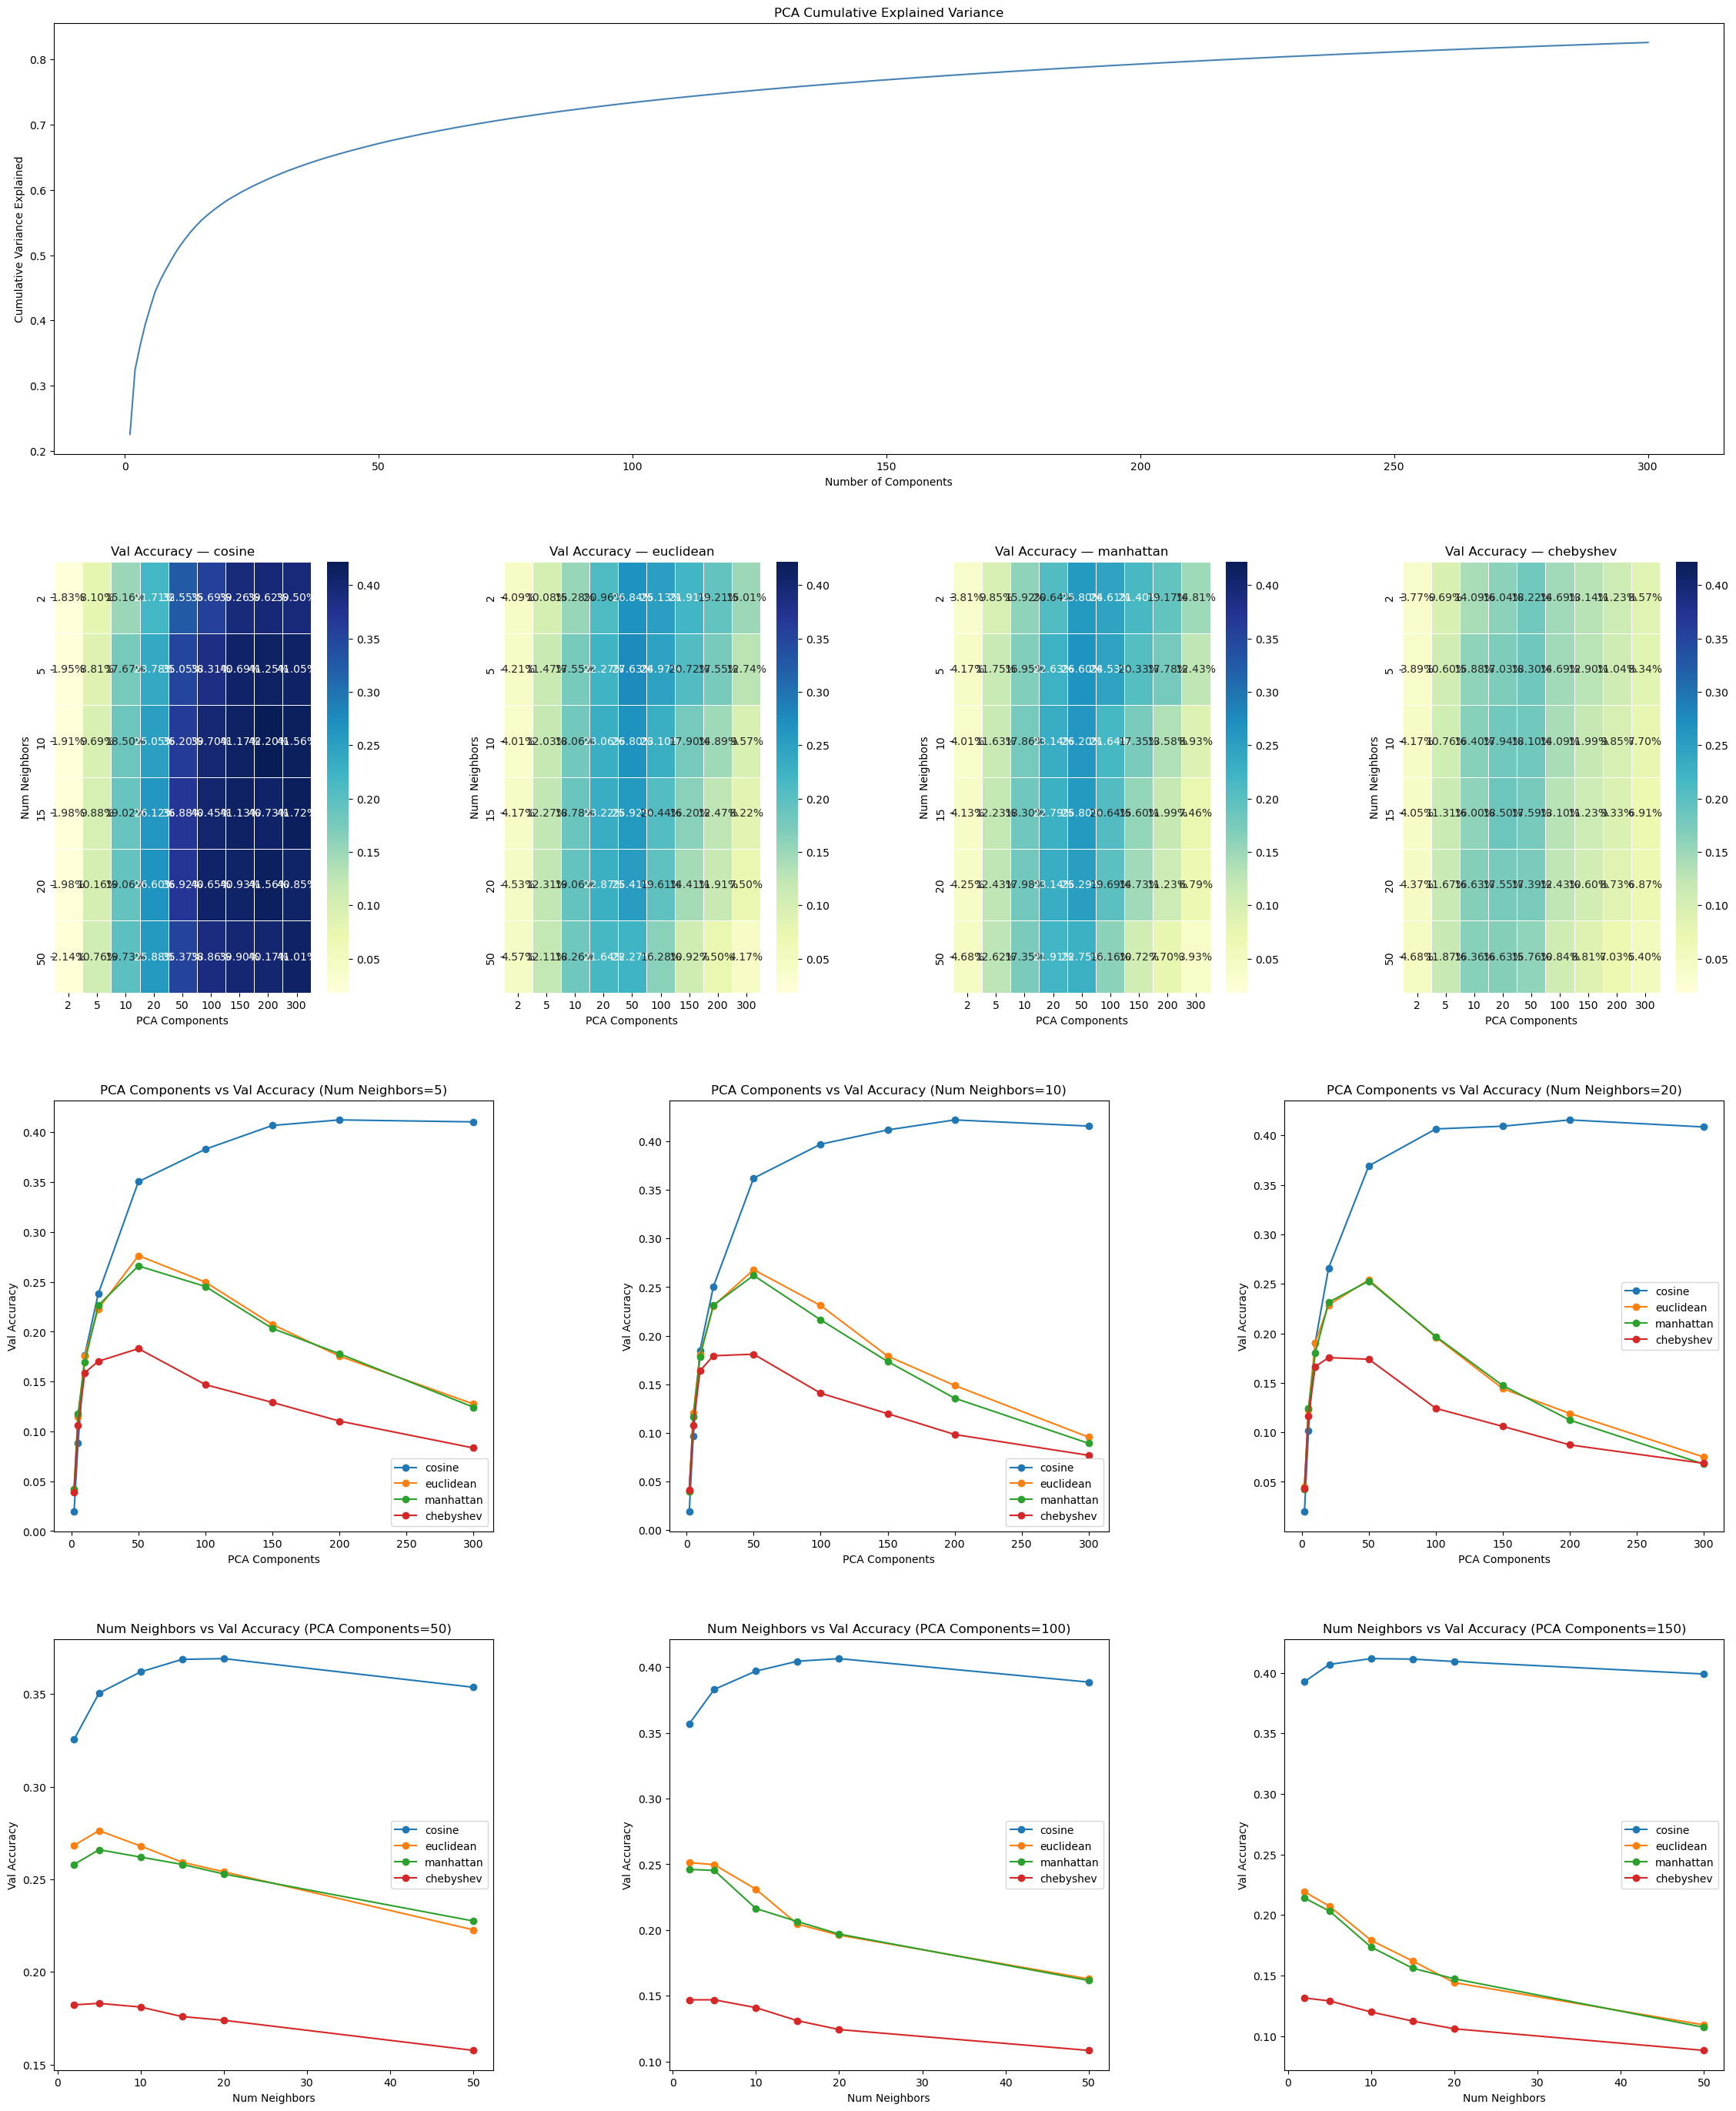

In [ ]:
num_neighbors_plot = [5, 10, 20]
pca_dimensions_plot = [50, 100, 150]

metrics = results_df['metric'].unique()
n_comp_vals = sorted(results_df['n_components'].unique())
vmin = results_df['val_accuracy'].min()
vmax = results_df['val_accuracy'].max()

fig = plt.figure(figsize=(7 * max(len(metrics), len(num_neighbors_plot), len(pca_dimensions_plot)), 28))

gs1 = gridspec.GridSpec(1, 1, figure = fig, top = 0.97, bottom = 0.77)
gs2 = gridspec.GridSpec(1, len(metrics), figure = fig, top = 0.72, bottom = 0.52, wspace = 0.4)
gs3 = gridspec.GridSpec(1, len(num_neighbors_plot), figure = fig, top = 0.47, bottom = 0.27, wspace = 0.4)
gs4 = gridspec.GridSpec(1, len(pca_dimensions_plot), figure = fig, top = 0.22, bottom = 0.02, wspace = 0.4)

# Row 1: PCA cumulative variance
pca_ax = fig.add_subplot(gs1[0, 0])
pca_ax.plot(range(1, MAX_PCA + 1), np.cumsum(pca.explained_variance_ratio_), color = 'steelblue')
pca_ax.set(title = 'PCA Cumulative Explained Variance', xlabel = 'Number of Components', ylabel = 'Cumulative Variance Explained')
pca_ax.grid(False)

# Row 2: PCA dimensions vs num neighbors heatmap, one per distance metric
for i, metric in enumerate(metrics):
    ax = fig.add_subplot(gs2[0, i])
    pivot = (results_df[results_df['metric'] == metric]
             .pivot(index = 'n_neighbors', columns = 'n_components', values = 'val_accuracy'))
    sns.heatmap(pivot, annot = True, fmt='.2%', cmap = 'YlGnBu',
                vmin = vmin, vmax = vmax, ax = ax, linewidths = 0.5)
    ax.set_title(f'Val Accuracy — {metric}')
    ax.set_xlabel('PCA Components')
    ax.set_ylabel('Num Neighbors')

# Row 3: PCA dimensions vs val accuracy for fixed num neighbors values
for i, neighbors in enumerate(num_neighbors_plot):
    ax = fig.add_subplot(gs3[0, i])
    subset = results_df[results_df['n_neighbors'] == neighbors]
    for metric in metrics:
        data = subset[subset['metric'] == metric].sort_values('n_components')
        ax.plot(data['n_components'], data['val_accuracy'], marker = 'o', label = metric)
    ax.set(title = f'PCA Components vs Val Accuracy (Num Neighbors = {neighbors})',
           xlabel = 'PCA Components', ylabel = 'Val Accuracy')
    ax.legend()

# Row 4: num neighbors vs val accuracy for fixed PCA dimensions
for i, pca_dim in enumerate(pca_dimensions_plot):
    ax = fig.add_subplot(gs4[0, i])
    subset = results_df[results_df['n_components'] == pca_dim]
    for metric in metrics:
        data = subset[subset['metric'] == metric].sort_values('n_neighbors')
        ax.plot(data['n_neighbors'], data['val_accuracy'], marker = 'o', label = metric)
    ax.set(title = f'Num Neighbors vs Val Accuracy (PCA Components = {pca_dim})',
           xlabel = 'Num Neighbors', ylabel = 'Val Accuracy')
    ax.legend()

plt.show()

## Cell 6 — Predict test set with best model

In [ ]:
# Refit best model from grid search on full training set before predicting test
best_n_comp = int(results_df.iloc[0]['n_components'])
best_k = int(results_df.iloc[0]['n_neighbors'])
best_metric = results_df.iloc[0]['metric']
best_knn = KNeighborsClassifier(n_neighbors = best_k, metric = best_metric, weights = 'distance', n_jobs = -1)
best_knn.fit(X_train_pca[:, :best_n_comp], y_train)

# Load test images and apply same scaler + PCA transform as training
test_files = sorted([f for f in os.listdir(TEST_IMG_DIR) if f.endswith('.jpg')])
X_test_raw = np.array([load_image(f, TEST_IMG_DIR) for f in test_files], dtype = np.float32)
X_test_pca = pca.transform(scaler.transform(X_test_raw))[:, :best_n_comp]

# Make predictions and decode integer labels back to class name strings
preds_labels = le.inverse_transform(best_knn.predict(X_test_pca))
ids = [f.replace('.jpg', '') for f in test_files]

# Save predictions to timestamped CSV
timestamp  = datetime.now().strftime("%Y%m%d_%H%M%S")
submission_file = os.path.join(SUBMISSION_PATH, f"submission_knn_{timestamp}.csv")
df_out = pd.DataFrame({'ID': ids, 'TARGET': preds_labels})
df_out.to_csv(submission_file, index = False)